# MLP from Scratch on MNIST


## MLP to classify handwritten digits

MNIST is a dataset of handwritten digits (0–9). Each image is $28 \times 28$ grayscale pixels and we want to classify it into one of 10 classes. We build a function $f_\theta : \mathbb{R}^{784} \to \mathbb{R}^{10}$ parameterized by weights $\theta = \{W_i, b_i\}_{i \in I}$.

For a 3-layer MLP (2 hidden + 1 output), the forward pass is:

$$
\begin{aligned}
h_1 &= \text{ReLU}(W_1 x + b_1) \\
h_2 &= \text{ReLU}(W_2 h_1 + b_2) \\
z &= W_3 h_2 + b_3
\end{aligned}
$$

##### Dimensions I choose for my Neural Network :

- Input: image of $28 \times 28 = 784$ pixels, flattened → $x \in \mathbb{R}^{784}$
- Hidden 1: $W_1 \in \mathbb{R}^{64 \times 784}$, $b_1 \in \mathbb{R}^{64}$ → $h_1 \in \mathbb{R}^{64}$
- Hidden 2: $W_2 \in \mathbb{R}^{32 \times 64}$, $b_2 \in \mathbb{R}^{32}$ → $h_2 \in \mathbb{R}^{32}$
- Output: $W_3 \in \mathbb{R}^{10 \times 32}$, $b_3 \in \mathbb{R}^{10}$ → $z \in \mathbb{R}^{10}$ 

**In batched form**, we pass $B$ samples at a time. The input becomes $X \in \mathbb{R}^{B \times 784}$ and the output $Z \in \mathbb{R}^{B \times 10}$.

![MLP Architecture](mlp_architecture.png)

## 2. Setup — imports

In [13]:
# TODO: import the libraries you need
#   - torch (we build the MLP from scratch, so mostly raw tensors)
#   - torchvision + torchvision.transforms (MNIST)
#   - matplotlib.pyplot (plots)

import torch
import torchvision
from torchvision.transforms import v2

#from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import numpy as np

In [6]:
# TODO: pick the device ('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
# TODO: set a manual seed for reproducibility

Using cpu device


## 3. Data — MNIST

MNIST contains 60 000 training images and 10 000 test images of handwritten digits, 28×28 grayscale.

Each pixel is in $[0, 255]$. We normalize to $[0, 1]$ with `transforms.ToTensor()`, which also converts to a `(1, 28, 28)` float tensor.

In [41]:
# TODO: load MNIST train and test sets with transforms.ToTensor()
training_data = datasets.MNIST(
    root="data", train=True, download=True, transform=ToTensor()
)
test_data = datasets.MNIST(
    root="data", train=False, download=True, transform=ToTensor()
)
# TODO: wrap them in DataLoaders (choose a batch size, shuffle the train set)
batch_size = 64
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

100.0%
100.0%
100.0%
100.0%


torch.Size([64, 1, 28, 28]) torch.Size([64])


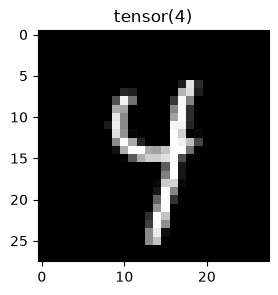

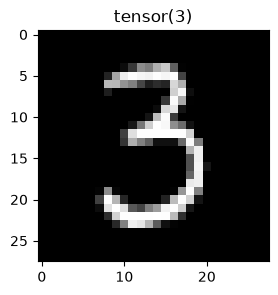

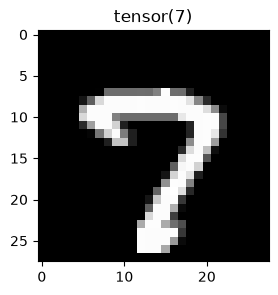

In [43]:
# TODO: plot a few MNIST samples (e.g. a 2x5 grid) together with their labels
images, labels = next(iter(train_dataloader))

print(images.shape,labels.shape) #batch_size de 64, 28*28 pixels

import random

labels_map = [
    "T-Shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
]

for i in range(3):
    plt.figure(figsize=(3,3))
    r = random.randint(0,batch_size-1)
    img = images[r].squeeze()
    plt.imshow(img, cmap="gray")
    plt.title(labels[r])






## 4. The Linear Layer

We implement a single fully-connected layer $f : \mathbb{R}^{d_\text{in}} \to \mathbb{R}^{d_\text{out}}$ defined by:

$$f(x) = x W^T + b \qquad W \in \mathbb{R}^{d_\text{out} \times d_\text{in}}, \quad b \in \mathbb{R}^{d_\text{out}}$$

### Weight initialization — He init

The choice of initial values for $W$ matters. If the weights are too large, activations explode through the layers. If too small, they vanish.

**He initialization** (Kaiming, 2015) sets:

$$W_{ij} \sim \mathcal{N}\!\left(0,\ \frac{2}{d_\text{in}}\right)$$

The factor $2$ comes from the ReLU activation, which zeroes out half the neurons on average, so the effective variance is halved at each layer. Multiplying by $2$ compensates for this.

In practice we sample from $\mathcal{N}(0, 1)$ and multiply by $\sigma = \sqrt{2 / d_\text{in}}$:

```python
W = torch.randn(out_features, in_features) * math.sqrt(2 / in_features)
```

**Why is this equivalent?** If $X \sim \mathcal{N}(0, 1)$ and $Y = \sigma X$, then:

$$\mathbb{E}[Y] = \sigma \,\mathbb{E}[X] = 0$$

$$\text{Var}(Y) = \sigma^2 \,\text{Var}(X) = \sigma^2 \cdot 1 = \sigma^2$$

Since $Y$ is a linear transform of a Gaussian, it is also Gaussian. Therefore:

$$Y \sim \mathcal{N}(0,\ \sigma^2) = \mathcal{N}\!\left(0,\ \frac{2}{d_\text{in}}\right)$$

The two sampling strategies are mathematically identical.

In [65]:
import math
class LinearScratch:
    # TODO: implement a fully-connected layer FROM SCRATCH (no nn.Linear)
    #   __init__  : initialise W (in_dim x out_dim) and b
    #   forward(x): return x @ W + b   (cache x for the backward)
    #   backward(grad_out): compute the grads wrt W, b and the input x
    # See the explanation in the markdown cell above.

    def __init__(self,iD,oD,device='cpu'):
        self.b = torch.zeros(oD,device=device,requires_grad = True)
        self.W = torch.randn(oD,iD,device=device) * math.sqrt(2/iD)
        self.W.requires_grad=True
    
    def __call__(self,x):
        return x @ self.W.T + self.b
    
    def parameters(self):
        return [self.W, self.b]
        

## 5. The full MLP
We have : 
$$
\begin{aligned}
h_1 &= \text{ReLU}(W_1 x + b_1) \\
h_2 &= \text{ReLU}(W_2 h_1 + b_2) \\
y &= W_3 h_2 + b_3
\end{aligned}
$$

In [64]:
class MLP:
    # TODO: assemble the MLP from LinearScratch layers + ReLU (e.g. 784 -> 128 -> 10)
    #   forward(x) : linear -> ReLU -> linear   (cache the activations)
    #   backward(grad) : backprop through the layers
    #   params() : return all learnable tensors

    def __init__(self):
        self.fc1 = LinearScratch(28*28,64)
        self.fc2 = LinearScratch(64,32)
        self.fc3 = LinearScratch(32,10)
    
    def __call__(self,x):
        h1 = torch.relu(self.fc1(x))
        h2 = torch.relu(self.fc2(h1))
        y = self.fc3(h2)
        return y
    
    def parameters(self):
        return self.fc1.parameters() + self.fc2.parameters() + self.fc3.parameters()


## 6. The loss : Cross-Entropy

For classification we use **cross-entropy**. The output of our network is $Z \in \mathbb{R}^{B \times 10}$ — for each of the $B$ samples, we get a vector of 10 raw scores. We now turn them into a loss.

### Step 1 : Softmax

For sample $k$, we turn its score vector $z^{(k)} \in \mathbb{R}^{10}$ into a probability distribution:

$$p_i^{(k)} = \text{softmax}(z_i^{(k)}) = \frac{e^{z_i^{(k)}}}{\sum_{j=1}^{10} e^{z_j^{(k)}}}$$

### Step 2 : Negative log-likelihood

Given the true class $y^{(k)} \in \{0, 1, \dots, 9\}$, the loss for sample $k$ is:

$$\mathcal{L}_k = -\log p_{y^{(k)}}^{(k)}$$

### Combined : log-softmax + NLL

Computing softmax then taking the log is numerically unstable (the exponentials can overflow). Instead we use the **log-softmax trick**:

$$\log p_i^{(k)} = z_i^{(k)} - \log \sum_{j=1}^{10} e^{z_j^{(k)}}$$

The second term is computed with the **logsumexp trick**. Let $m = \max_{j \in \{1,\dots,10\}} z_j^{(k)}$:

$$\sum_{j=1}^{10} e^{z_j^{(k)}} = \sum_{j=1}^{10} e^{z_j^{(k)} - m + m} = e^m \sum_{j=1}^{10} e^{z_j^{(k)} - m}$$

Taking the log:

$$\log \sum_{j=1}^{10} e^{z_j^{(k)}} = m + \log \sum_{j=1}^{10} e^{z_j^{(k)} - m}$$

Since $z_j^{(k)} - m \leq 0$ for all $j$, every term $e^{z_j^{(k)} - m} \in ]0, 1]$ — no overflow possible.

So we have:

$$\mathcal{L}_k = - z_{y^{(k)}}^{(k)} + m + \log \sum_{j=1}^{10} e^{z_j^{(k)} - m}$$

### Final formula for a batch

The total loss is the average over the batch:

$$\mathcal{L} = \frac{1}{B} \sum_{k=1}^{B} \mathcal{L}_k = \frac{1}{B} \sum_{k=1}^{B} \left( \log \sum_{j=1}^{10} e^{z_j^{(k)} - m} - \left(z_{y^{(k)}}^{(k)} - m\right) \right)$$

In [53]:
def cross_entropy_scratch(logits, targets):

    B = logits.shape[0]

    m = logits.max(dim=1).values                  # (B,)
    stable_logits = logits - m.unsqueeze(1)       # (B, 10)
    
    log_sum_exp = stable_logits.exp().sum(dim=1).log()     # (B,)

    true_class_logits = logits[torch.arange(B), targets]   # (B,)

    lk = log_sum_exp -true_class_logits + m            # (B,)

    return lk.mean()

## 8. Optimizer : Stochastic Gradient Descent (SGD)

The gradient $\nabla_\theta \mathcal{L}$ tells us the direction in which the loss increases the most. To **minimize** the loss, we go in the opposite direction:

$$\theta_{t+1} = \theta_t - \eta \cdot \nabla_\theta \mathcal{L}(\theta_t)$$

where $\eta$ is the **learning rate** 


### The autograd workflow

1. **Forward pass** — compute logits and loss
2. **Backward pass** — call `loss.backward()`. PyTorch builds the computation graph during the forward pass and automatically computes $\nabla_\theta \mathcal{L}$ for every tensor with `requires_grad=True`. The gradients are stored in `p.grad`.
3. **Update** — apply $p \leftarrow p - \eta \cdot p.\text{grad}$
4. **Zero the gradients** — PyTorch *accumulates* gradients by default, so we must reset them before the next step

**Important:** the update must happen inside `torch.no_grad()` so it doesn't get tracked by autograd.

In [67]:
def sgd_step(params, lr):
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad
            p.grad.zero_() 

## 9. Training loop

For each epoch:
1. Iterate over batches of the training set
2. Forward → loss → backward → SGD step
3. Log the running loss
4. At the end of the epoch, evaluate on the test set

In [58]:
def evaluate(model, loader, device):
    
    correct = 0
    total = 0 
    with torch.no_grad():
        for x,y in loader:
            x = x.view(x.size(0),-1).to(device)
            y = y.to(device)

            logits = model(x)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct/total

In [68]:
# Hyperparameters
# TODO: set EPOCHS, LR, hidden size, ...
EPOCHS = 10
LR = 0.05

model = MLP()

train_losses = []
test_accuracies = []

# TODO: training loop
#   for each epoch:
#     for each batch -> forward -> cross_entropy_scratch -> backward -> sgd_step
#     track train loss/acc, then evaluate() on the test set
#   keep the curves (train/test loss and accuracy) for the plots below

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for x,y in train_dataloader:
        x = x.view(x.size(0), -1).to(device)   
        y = y.to(device)

        logits = model(x)                        
        loss = cross_entropy_scratch(logits, y)  

        loss.backward()                          
        sgd_step(model.parameters(), LR)        

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dataloader)
    
    test_acc = evaluate(model, test_dataloader, device)
    train_losses.append(avg_loss)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1:2d} | avg loss = {avg_loss:.4f} | test_acc = {test_acc:.4f}")

Epoch  1 | avg loss = 0.4344 | test_acc = 0.9276
Epoch  2 | avg loss = 0.2150 | test_acc = 0.9470
Epoch  3 | avg loss = 0.1648 | test_acc = 0.9530
Epoch  4 | avg loss = 0.1354 | test_acc = 0.9569
Epoch  5 | avg loss = 0.1152 | test_acc = 0.9606
Epoch  6 | avg loss = 0.1001 | test_acc = 0.9645
Epoch  7 | avg loss = 0.0883 | test_acc = 0.9654
Epoch  8 | avg loss = 0.0790 | test_acc = 0.9666
Epoch  9 | avg loss = 0.0714 | test_acc = 0.9678
Epoch 10 | avg loss = 0.0650 | test_acc = 0.9694


In [69]:
import os

save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)

checkpoint = {
    'fc1_W': model.fc1.W,
    'fc1_b': model.fc1.b,
    'fc2_W': model.fc2.W,
    'fc2_b': model.fc2.b,
    'fc3_W': model.fc3.W,
    'fc3_b': model.fc3.b,
    'test_accuracy': test_accuracies[-1],
    'epochs': EPOCHS,
    'lr': LR,
}

torch.save(checkpoint, os.path.join(save_dir, "mlp_scratch.pt"))
print(f"Model saved → {save_dir}/mlp_scratch.pt")
print(f"Final test accuracy: {test_accuracies[-1]:.4f}")

Model saved → checkpoints/mlp_scratch.pt
Final test accuracy: 0.9694


## 10. Learning curves

In [71]:
checkpoint = torch.load("checkpoints/mlp_scratch.pt")
model = MLP()
model.fc1.W = checkpoint['fc1_W']
model.fc1.b = checkpoint['fc1_b']
model.fc2.W = checkpoint['fc2_W']
model.fc2.b = checkpoint['fc2_b']
model.fc3.W = checkpoint['fc3_W']
model.fc3.b = checkpoint['fc3_b']

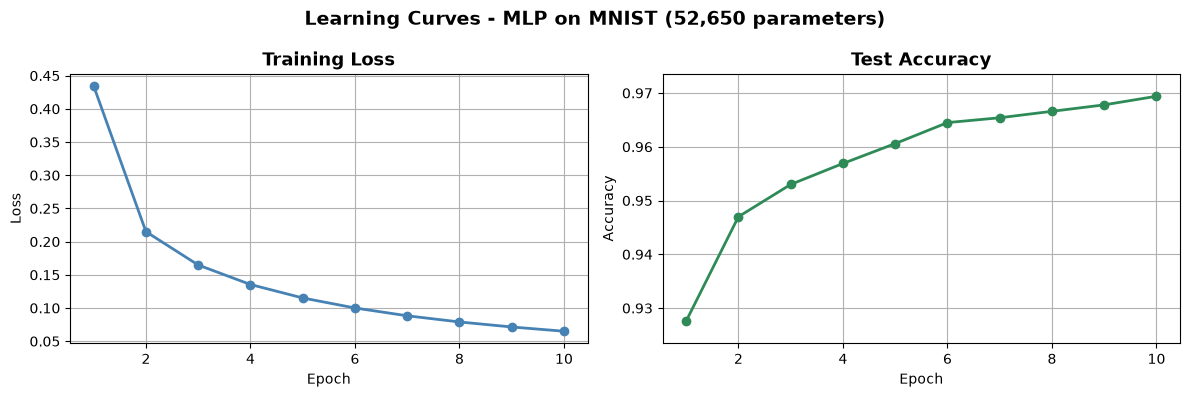

In [72]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_losses, color='steelblue', linewidth=2, marker='o')
ax1.set_title('Training Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(epochs_range, test_accuracies, color='seagreen', linewidth=2, marker='o')
ax2.set_title('Test Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
margin = (max(test_accuracies) - min(test_accuracies)) * 0.1
ax2.set_ylim(min(test_accuracies) - margin, max(test_accuracies) + margin)
ax2.grid(True)

n_params = sum(p.numel() for p in model.parameters())
plt.suptitle(f'Learning Curves - MLP on MNIST ({n_params:,} parameters)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Visualize predictions

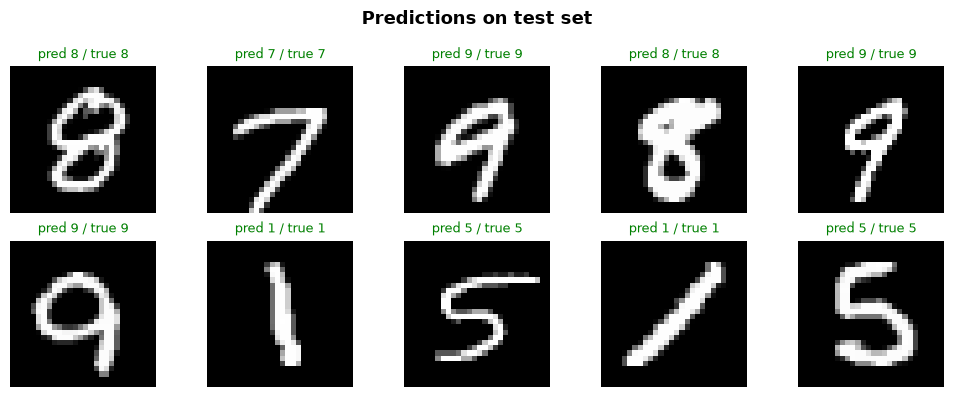

In [84]:
indices = torch.randint(0, len(test_data), (10,))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    image, true_label = test_data[indices[i]]
    x = image.view(1, -1).to(device)              

    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=1).item()

    ax.imshow(image.squeeze(), cmap='gray')
    color = 'green' if pred == true_label else 'red'
    ax.set_title(f'pred {pred} / true {true_label}', color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Predictions on test set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()